## <font color = '#6495ED'>  ______________________ **Text Mining - Stock Sentiment** _____________________
#### _______________________________________________Academic Year: 2024/2025 _____________________________________________

<div style="text-align: center;">
    <strong>Group 31</strong>
    <table style="margin: 0 auto; border-collapse: collapse; border: 1px solid black;">
        <tr>
            <th style="border: 1px solid white; padding: 8px;">Name</th>
            <th style="border: 1px solid white; padding: 8px;">Student ID</th>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">David XPTO</td>
            <td style="border: 1px solid white; padding: 8px;">22222222</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Elcano Gaspar</td>
            <td style="border: 1px solid white; padding: 8px;">20241021</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Jorge Cordeiro</td>
            <td style="border: 1px solid white; padding: 8px;">20240594</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Rui Reis</td>
            <td style="border: 1px solid white; padding: 8px;">20240854</td>
        </tr>
    </table>
</div>

### <font color = '#6495ED'> **Index**</font>

1. [Libraries, Functions, Configuration, and Datasets](#libraries-functions-configuration-and-datasets)  
    1.1. [Import the Needed Libraries](#import-the-needed-libraries)  
    1.2. [Setup and Configuration](#setup-and-configuration)  
    1.3. [Import the Dataset](#import-the-dataset)  

2. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)  
    2.1. [Exploration of the Data](#exploration-of-the-data)  
    2.2. [Shape Difference in Datasets](#shape-difference-in-datasets)  
    2.3. [Check Class Balance](#check-class-balance)  
    2.4. [Date Type Features Analysis](#data-type-features-analysis)  
    2.5. [Numerical Summaries](#numerical-summaries)  
    2.6. [Check Duplicates](#check-duplicates)  
    2.7. [Check for Missing Values](#check-for-missing-values)  
    2.8. [Correlation Analysis](#correlation-analysis)  
    2.9. [Categorical Variable Analysis](#categorical-variable-analysis)  
    2.10. [Univariate Analysis](#univariate-analysis)  
    2.11. [Outliers Analysis](#outliers-analysis)  

3. [Data Preprocessing](#data-preprocessing)  
    3.1. [Set the Index](#set-the-index)  
    3.2. [Split the Data](#split-the-data)  
    3.3. [Fix Data Types](#fix-data-types)  
    3.4. [Treat Outliers](#treat-outliers)  
    3.5. [Treat Missing Values](#treat-missing-values)  

4. [Feature Engineering](#feature-engineering)  
    4.1. [Create New Variables](#create-new-variables)  
    
5. [Multivariable Analysis](#multivariable-analysis)  
    5.1. [Numerical vs Numerical](#numerical-vs-numerical)  
    5.2. [Categorical vs Categorical](#categorical-vs-categorical)  
    5.3. [Numerical vs Categorical](#numerical-vs-categorical)   

### <font color = '#6495ED'>**Introduction**</font>

#### *Objective:*
The goal of this project is to develop an NLP model capable of predicting stock market sentiment analysis from tweets using both traditional and transformer-based NLP models.
#### *Corpora:*
- Training Dataset: Presents the tweets (“text”) and the sentiment label (“label”). Each tweet can have one of the following labels: Bearish (0), Bullish (1), or Neutral (2). Bullish is typically a positive market performance, while bearish is the opposite.
- Test Dataset: The structure of these dataset is the same as the train set, except that it does not contain the “label” column.
#### *Methodology:*
The project will follow these steps:
- Exploratory Data Analysis (EDA)
- Corpus split
- Data Preprocessing
- Feature Engineering
- Classification Models
#### *Success Metrics:*
Our primary metric will be F1 Score, Recall and Precision, as we are dealing with an imbalanced class problem, but also the Accuracy.
#### **Variable description:**

| **ATTRIBUTE**               | **DESCRIPTION**                                                                                   |
|-----------------------------|---------------------------------------------------------------------------------------------------|
| text               | Tweets about market stocks.                                                                         |
| label               | Market sentiment Bearish (0), Bullish (1), or Neutral (2).                                                  |

### <font color = '#6495ED'>  **1. Libraries, Functions, Configuration and Datasets** </font>

#### <font color = '#6495ED'> **1.1. Import the Needed Libraries** </font>

In [110]:
# Data Handling
import pandas as pd
import numpy as np
from collections import Counter

# Model Evaluation & Splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Preprocessing
import re
import string
import time
from tqdm import tqdm
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# LLM Integration
import openai

In [66]:
#Data management
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import pointbiserialr

from collections import Counter

# Emojis analysis
import emoji

from sklearn.metrics import classification_report

#Preprocessing
import string
from tqdm import tqdm
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

#Visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image 
import seaborn as sns
from textblob import TextBlob
import plotly.express as px 

import openai
import time
from tqdm import tqdm

#### <font color = '#6495ED'> **1.2. Setup and Configuration** </font>

In [67]:
# Set display options to show full text
pd.set_option('display.max_colwidth', None)  # No truncation of text
pd.set_option('display.max_rows', None)     # Show all rows

In [68]:
#!pip install python-dotenv

In [69]:
# Set seaborn style and matplotlib defaults
sns.set(style="whitegrid", color_codes= "#152645", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.dpi'] = 100

#### <font color = '#6495ED'>**1.3. Load the Dataset** </font>

In [102]:
train_df = pd.read_csv('train.csv')

# Get 5 examples for each label
label_0_examples = train_df[train_df['label'] == 0].head(10)
label_1_examples = train_df[train_df['label'] == 1].head(10)
label_2_examples = train_df[train_df['label'] == 2].head(10)

# Combine and print the results
examples = pd.concat([label_0_examples, label_1_examples, label_2_examples])
print(examples[['text', 'label']].to_string(index=False))

                                                                                                     text  label
                            $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT      0
   $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3      0
           $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb      0
                                              $ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N      0
                                  $FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB      0
   $FTI - TechnipFMC downgraded at Berenberg but called Top Pick at Deutsche Bank https://t.co/XKcPDilIuU      0
                                                            $GM - GM loses a bull https://t.co/tdUfG5HbXy      0
                                                  $GM: Deutsche Bank cuts to Hold https://t.co/7

In [71]:
test = pd.read_csv('test.csv')
test.head(30)

,id,text
0,0,"ETF assets to surge tenfold in 10 years to $50 trillion, Bank of America predicts"
1,1,Here’s What Hedge Funds Think Evolution Petroleum Corporation (EPM)
2,2,$PVH - Phillips-Van Heusen Q3 2020 Earnings Preview https://t.co/kNhCYwVnBX
3,3,"China is in the process of waiving retaliatory tariffs on imports of U.S. pork and soy by domestic companies, a pro… https://t.co/08mZU9TrBX"
4,4,"Highlight: “When growth is scarce, investors seem very willing to pay up for growth stock"" @PNCBank's… https://t.co/rO4fBOkBG9"
5,5,Marvell Technology (MRVL) Gains As Market Dips: What You Should Know - Nasdaq
6,6,UPDATE 1-Italian airline Alitalia's rescue in doubt as Atlantia backtracks
7,7,why macro funds are shutting down left and right https://t.co/gVYowOBmqe
8,8,Uber's arrival caused binge drinking to increase up to 21.8% and a possible decrease in drunk driving. Here's a lo… https://t.co/4h7tuhLp1B
9,9,New Dungeons & Dragons game announced


In [72]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB


In [73]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2388 non-null   int64 
 1   text    2388 non-null   object
dtypes: int64(1), object(1)
memory usage: 37.4+ KB


In [74]:
train_df.isna().sum()

text     0
label    0
dtype: int64

In [75]:
test.isna().sum()

id      0
text    0
dtype: int64

In [76]:
train_df.describe()

,label
count,9543.000000
mean,1.496280
std,0.743139
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


### <font color = '#6495ED'> **3. Preprocessing** </font>

#### <font color = '#6495ED'> **3.1. Corpus split** </font>

In [77]:
# Split
train, val = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['label'],  # preserves class distribution
    random_state=42
)

# Display proportions
print("Train label distribution:\n", train['label'].value_counts(normalize=True))
print("Validation label distribution:\n", val['label'].value_counts(normalize=True))


Train label distribution:
 label
2    0.647367
1    0.201467
0    0.151166
Name: proportion, dtype: float64
Validation label distribution:
 label
2    0.647459
1    0.201676
0    0.150864
Name: proportion, dtype: float64


In [78]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7634 entries, 2186 to 7664
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7634 non-null   object
 1   label   7634 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 178.9+ KB


In [79]:
val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1909 entries, 4693 to 3945
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1909 non-null   object
 1   label   1909 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 44.7+ KB


#### <font color = '#6495ED'> **3.2. Data Cleaning for Generative Models** </font>

In [80]:
def clean_for_generative_models(text_list):
    """
    Cleans text for generative models while preserving sentiment signals.
    Args:
        text_list: List of raw tweet strings
    Returns:
        List of cleaned tweet strings
    """
    cleaned = []
    
    for text in tqdm(text_list, desc="Cleaning tweets"):
        # URL normalization
        text = re.sub(r"https?://\S+|www\.\S+", "[URL]", text)
        # Handle tickers and mentions
        text = re.sub(r"\$\w+", "[TICKER]", text)  # Standardize tickers
        text = re.sub(r"@\w+", "[USER]", text)     # Standardize mentions
        # Preserve hashtag context but remove symbol
        text = re.sub(r"#(\w+)", r"\1", text)
        # Normalize whitespace
        text = re.sub(r"\s+", " ", text).strip()
        
        cleaned.append(text)
    
    return cleaned

In [81]:
train["clean_text"] = clean_for_generative_models(train["text"])

Cleaning tweets: 100%|██████████| 7634/7634 [00:00<00:00, 109240.68it/s]


In [82]:
val["clean_text"]   = clean_for_generative_models(val["text"])

Cleaning tweets: 100%|██████████| 1909/1909 [00:00<00:00, 396186.36it/s]


In [83]:
test["clean_text"]  = clean_for_generative_models(test["text"])

Cleaning tweets: 100%|██████████| 2388/2388 [00:00<00:00, 94536.92it/s]


In [84]:
print(train['clean_text'].head(10))

2186                                                                            Nasdaq prices 600M of 0.875% senior notes
6819                                                                                                     Futures up [URL]
6157                                       [TICKER]: November Nonfarm Private Payrolls 125K vs 153K [URL] consensus [URL]
2462                 Twitter users explain why Kohl's stock just got obliterated after reporting earnings [URL] by… [URL]
4097    Agilysys : Restaurants Find Sustainable Methods for Limiting Food Waste During the Holidays Agilysys Stock… [URL]
4830                              Make the Most of Your Retirement with These Top-Ranked Mutual Funds - February 07, 2020
8441               Could Applied DNA Sciences, Inc. (APDN) See a Reversal After Breaking Its 52 Week Low? - The Lamp News
4669                                                        How the USMCA Affects U.S. Steelmakers and Auto Manufacturers
2825                    

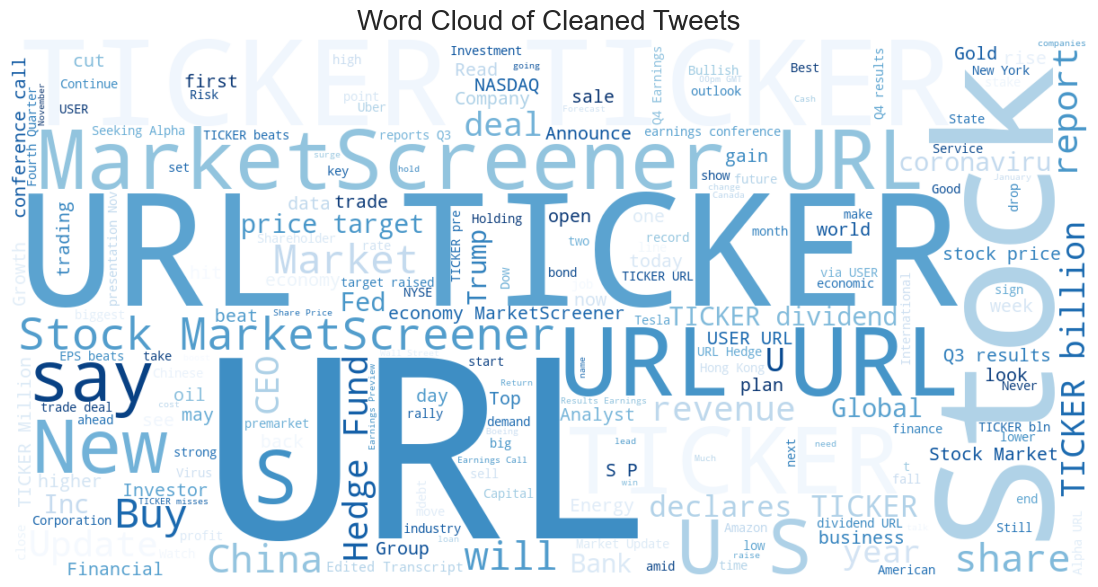

In [85]:
# Combine all clean text into one string
all_words = " ".join(train['clean_text'])

# Generate and display word cloud
wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap='Blues').generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Tweets', fontsize=20)
plt.show()

#### <font color = '#6495ED'> **3.3. Generative Models for Classification** </font>

##### <font color = '#6495ED'> **3.3.1. Fine-Tuning model: Mistral 7B** </font>

In [86]:
!pip install -q transformers accelerate datasets peft bitsandbytes


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Elcano\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [87]:
# Define Prompt Template and Preprocessing

from transformers import AutoTokenizer

# Define the prompt for classification
def format_prompt(example):
    prompt = f"Classify the sentiment of the tweet as Bearish (0), Bullish (1), or Neutral (2): '{example['text']}' Sentiment:"
    return {"prompt": prompt, "label": str(example["label"])}

# Load tokenizer
model_name = "mistralai/Mistral-7B-v0.1"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# Apply prompt formatting
train_dataset = train_dataset.map(format_prompt)
val_dataset = val_dataset.map(format_prompt)


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mistralai/Mistral-7B-v0.1.
401 Client Error. (Request ID: Root=1-6849dcf2-7bd890f020b0c53a30ffb67c;9b8837f6-57ef-47ff-86c5-9256e0c8f2f0)

Cannot access gated repo for url https://huggingface.co/mistralai/Mistral-7B-v0.1/resolve/main/config.json.
Access to model mistralai/Mistral-7B-v0.1 is restricted. You must have access to it and be authenticated to access it. Please log in.

In [ ]:
#Load Mistral 7B in 4-bit Mode
from transformers import AutoModelForCausalLM
import torch
from peft import prepare_model_for_kbit_training

# Load model in 4-bit precision
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    load_in_4bit=True,
    device_map="auto",
    trust_remote_code=True
)

# Prepare for LoRA fine-tuning
model = prepare_model_for_kbit_training(model)

In [ ]:
#Configure and Apply LoRA
from peft import LoraConfig, get_peft_model

# Define LoRA config
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Wrap model with LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

In [ ]:
#Tokenize Prompts
def tokenize(example):
    inputs = tokenizer(example["prompt"], truncation=True, padding="max_length", max_length=256)
    labels = tokenizer(example["label"], truncation=True, padding="max_length", max_length=8)
    inputs["labels"] = labels["input_ids"]
    return inputs

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

In [ ]:
#Train the Model
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./mistral-sentiment",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    evaluation_strategy="epoch",
    num_train_epochs=3,
    logging_dir="./logs",
    save_strategy="epoch",
    learning_rate=2e-4,
    bf16=False,  # T4 does not support bfloat16
    fp16=True,   # Use float16
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer
)

trainer.train()


In [ ]:
#Save and Push the Fine-Tuned Model
model.save_pretrained("fine-tuned-mistral-sentiment")
tokenizer.save_pretrained("fine-tuned-mistral-sentiment")

##### <font color = '#6495ED'> **3.3.2. Zero-Shot Classification with GPT-4o via Prompt Engineering** </font>

In [111]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path="C://Users/Elcano/Documents/NOVA IMS/2_Semester/Text Mining - NLP/Project/Project_NLP_Ecano/.env.txt")  # Adjust path as needed

# Reload variables
api_key = os.getenv("AZURE_OPENAI_API_KEY")
endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
deployment = os.getenv("AZURE_DEPLOYMENT_NAME")

In [112]:
from openai import AzureOpenAI

client = AzureOpenAI(
    api_key=api_key,
    api_version="2024-02-15-preview",  # or latest supported version
    azure_endpoint=endpoint
)

In [113]:
def evaluate_performance(y_true, y_pred):
    # Print classification report
    print(classification_report(y_true, y_pred, target_names=["Bearish", "Bullish", "Neutral"]))
    
    # Create and display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Bearish", "Bullish", "Neutral"],
                yticklabels=["Bearish", "Bullish", "Neutral"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [114]:

# System Prompt 
SYSTEM_PROMPT = (
    "You are a highly analytical and precise financial sentiment classifier for social media. "
    "Your core expertise is to rigorously determine the sentiment of stock market tweets. "
    "Your analysis must strictly adhere to established financial interpretations of Bullish, Bearish, and Neutral outlooks. "
    "Crucially, focus on explicit indicators such as price trends, market news, analyst actions, "
    "earnings reports, and the directional implications of company tickers and financial jargon. "
    "Strive for maximum accuracy and consistency in your classifications."
)

# Test a single call (optional debug)
response = client.chat.completions.create(
    model=deployment,  # Use Azure deployment name
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": "Classify this tweet: 'Market looking shaky today'"}
    ],
    temperature=0
)
print(response.choices[0].message.content.strip())

# Classification function using Azure
def gpt4o_classify(texts, deployment, max_retries=3):
    predictions = []

    for text in tqdm(texts):
        prompt = f"""Based on your expert financial analysis, classify the sentiment of the following stock market tweet. Your decision should reflect the primary market outlook conveyed by the tweet, considering all financial cues.

Output Format: Respond *only* with the single integer representing the sentiment (0, 1, or 2). No other words, explanations, or punctuation are permitted.

Sentiment Definitions:
- **Bearish (0):** Indicates a clear negative outlook or expectation of decline for a stock, company, or the broader market. Look for explicit mentions of price drops, selling pressure, downgrades, poor earnings, losses, or significant negative news.
- **Bullish (1):** Indicates a clear positive outlook or expectation of rise for a stock, company, or the overall market. Look for explicit mentions of price increases, buying interest, upgrades, strong earnings, gains, or significant positive news.
- **Neutral (2):** The tweet is factual, objective, or non-directional. It contains general information, news updates, or balanced viewpoints without a strong positive or negative market bias. **If the sentiment is ambiguous, mixed, or lacks a clear dominant directional bias (positive or negative), classify it as Neutral.**

Tweet: "{text}"
Sentiment:"""

        for attempt in range(max_retries):
            try:
                response = client.chat.completions.create(
                    model=deployment,
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": prompt}
                    ],
                    temperature=0,
                )
                result = response.choices[0].message.content.strip()
                predictions.append(int(result))
                break
            except Exception as e:
                time.sleep(1)
                if attempt == max_retries - 1:
                    print(f"Error for input: {text[:60]}... -> {e}")
                    predictions.append(None)

    return predictions

The sentiment of the tweet "Market looking shaky today" is classified as Bearish. The term "shaky" implies instability and uncertainty in the market, which typically indicates a negative outlook.


100%|██████████| 1909/1909 [19:22<00:00,  1.64it/s]


              precision    recall  f1-score   support

     Bearish       0.77      0.77      0.77       288
     Bullish       0.85      0.73      0.78       385
     Neutral       0.87      0.91      0.89      1236

    accuracy                           0.85      1909
   macro avg       0.83      0.80      0.81      1909
weighted avg       0.85      0.85      0.85      1909



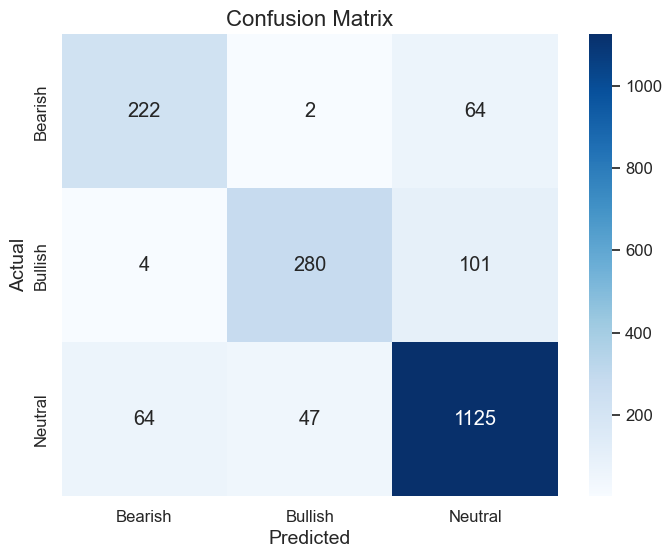

In [115]:
# Use pre-cleaned column
val_preds_gpt = gpt4o_classify(val["clean_text"].tolist(), deployment="gpt-4o-mini")

# Evaluate
evaluate_performance(val["label"], val_preds_gpt)

In [116]:
# Use pre-cleaned text
test_preds_gpt = gpt4o_classify(test["clean_text"].tolist(), deployment=deployment)

# Format submission
submission = pd.DataFrame({
    "id": test["id"],
    "label": test_preds_gpt
})

# Save CSV for Moodle
submission.to_csv("pred_31.csv", index=False)

100%|██████████| 2388/2388 [24:26<00:00,  1.63it/s]


===============================================================================================================